Fundamentals of Deep Learning Models

# Lab 03-3: Simple Deep Neural Network
## Exercise: Predicting MNIST digits with a three-layer neural network

This exercise extends Lab 03-2 to a **three-layer neural network** (two sigmoid hidden layers + softmax output) for handwritten digit classification. The network implements the full backpropagation procedure (Section 3.7) with gradient propagation through multiple hidden layers using Eq. 3.26, demonstrating the generalization of backpropagation to deeper architectures.

### Prepare mini-MNIST dataset

The scikit-learn digits dataset contains $N = 1797$ images of 8×8 pixels ($M = 64$ input features) with $K = 10$ digit classes (0–9). Feature standardization is applied to avoid overflow in exponential computations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version

print('Numpy version:', np.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('scikit-learn version:', sklearn_version)

Numpy version: 2.0.2
Matplotlib version: 3.10.0
scikit-learn version: 1.6.1


In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()

# digits.data: 1797 images of 8x8 pixels with handwritten digits
digits_df = digits.images.reshape((len(digits.target), -1))
digits_tf = digits.target

# Split dataset into 80% train and 20% test
X_train_org, X_test_org, y_train_num, y_test = train_test_split(digits_df, digits_tf, test_size= 0.20, random_state= 101)

# Standardize features to zero mean and unit variance for numerical stability
sc = StandardScaler()
X_train = sc.fit_transform(X_train_org)
X_test = sc.transform(X_test_org)

n_classes = 10

# Convert integer labels to one-hot encoding for cross-entropy loss (Eq. 3.16)
y_train = np.zeros((y_train_num.shape[0],10))
for i in range(n_classes):
    y_train[:,i] = (y_train_num == i)

#### Define utility functions

In [3]:
from tensorflow.math import sigmoid as tf_sigmoid
from tensorflow.nn import softmax as tf_softmax

def sigmoid(x):
    x = tf_sigmoid(x)
    return x.numpy()

def softmax(x):
    x = tf_softmax(x)
    return x.numpy()

(1797, 64)
(1437, 64)
(1437, 10)
[ 0.  0.  0.  9. 16.  6.  0.  0.  0.  0.  4. 15.  6. 15.  0.  0.  0.  0.
  8. 11.  9. 11.  0.  0.  0.  0.  8. 16. 14.  2.  0.  0.  0.  0. 11. 16.
 13.  0.  0.  0.  0.  6. 14.  2. 12.  9.  0.  0.  0.  5. 16. 11.  5. 13.
  4.  0.  0.  0.  3.  8. 13. 16.  9.  0.]


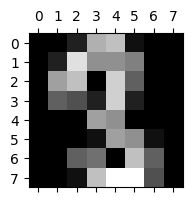

The number is 3


In [4]:
# Display dataset information and a sample image
print(digits_df.shape)
print(X_train.shape)
print(y_train.shape)
print(X_train_org[0])

idx = np.random.randint(X_train.shape[0])
dimage = X_train_org[idx].reshape((8,8))
plt.figure(figsize=(2,2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()
print('The number is', y_train_num[idx])

### Simple DNN for digit classification

#### Dense layer class (see Lab 03-2)

Each layer computes the linear transformation $\mathbf{z}^{[l]} = \mathbf{W}^{[l]}\mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}$ in the forward pass and computes parameter gradients (Eq. 3.27/3.39) and propagates gradients to the lower layer (Eq. 3.26) in the backward pass.

In [ ]:
class myDenseLayer:
    def __init__(self, n_out, n_in):
        self.weight = np.empty((n_out, n_in))   # (o, i)
        self.bias = np.zeros((n_out))
        self.saved_x = None     # store x for backpropagation

    def forward(self, x):   # x: (b, i)

        ### START CODE HERE ###

        # Store input for use in backpropagation (Section 3.6)
        self.saved_x = None
        # Compute linear combination: z = W * x^T + b  (forward, Section 3.6)
        x_lin = None

        ### END CODE HERE ###

        return x_lin

    def backward(self, x):  # x = dJ/dz (b, o)

        ### START CODE HERE ###

        # Compute weight gradient: dJ/dW = (1/N) * (dJ/dz)^T * a^[l-1]  (Eq. 3.39)
        dw = None
        # Compute bias gradient: dJ/db = (1/N) * sum(dJ/dz)  (Eq. 3.27)
        db = None
        # Propagate gradient to lower layer: dJ/dz * W  (used in Eq. 3.26)
        wdJdz = None

        ### END CODE HERE ###

        return dw, db, wdJdz


#### Activation function gradients (from Lab 03-2)

- `dJdz_softmax`: combined softmax–cross-entropy gradient $\partial J/\partial \mathbf{z}^{[L]} = \hat{\mathbf{y}} - \mathbf{y}$ (Eq. 3.23)
- `dJdz_sigmoid`: hidden-layer gradient via $\sigma'(\mathbf{z}^{[l]}) = \mathbf{a}^{[l]}(1-\mathbf{a}^{[l]})$ applied element-wise (Eq. 3.26)

In [ ]:
def dJdz_sigmoid(wdJdz_upper, az):

    ### START CODE HERE ###

    # Apply sigmoid derivative: (W^T * dJ/dz_upper) * a*(1-a)  (Eq. 3.26)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

def dJdz_softmax(y_hat, y):

    ### START CODE HERE ###

    # Softmax-cross-entropy gradient: dJ/dz = y_hat - y  (Eq. 3.23)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

#### Define training functions

The forward, backward, loss, and predict functions generalize the two-layer implementation from Lab 03-2 to three layers. The backward pass chains gradient propagation through layers 3 → 2 → 1 following the procedure in Section 3.7 (Steps 1–7).

In [ ]:
def my_forward(l1, l2, l3, X_in):

    ### START CODE HERE ###

    # Layer 1: sigmoid hidden layer
    a_1 = None
    # Layer 2: sigmoid hidden layer
    a_2 = None
    # Layer 3: softmax output layer (Eq. 3.13)
    a_3 = None

    ### END CODE HERE ###

    return a_1, a_2, a_3

def my_backward(l1, l2, l3, a_1, a_2, a_3, y_true):

    ### START CODE HERE ###

    # Layer 3 backward: softmax-CE gradient (Eq. 3.23) + parameter gradients (Eq. 3.27)
    dw_3, db_3, wdJdz_3 = None
    # Layer 2 backward: sigmoid gradient (Eq. 3.26) + parameter gradients
    dw_2, db_2, wdJdz_2 = None
    # Layer 1 backward: sigmoid gradient (Eq. 3.26) + parameter gradients
    dw_1, db_1, _       = None

    ### END CODE HERE ###

    d_1 = [dw_1, db_1]
    d_2 = [dw_2, db_2]
    d_3 = [dw_3, db_3]

    return d_1, d_2, d_3

def my_loss(l1, l2, l3, X_in, y_true):

    ### START CODE HERE ###

    # Forward pass and compute cross-entropy loss (Eq. 3.16)
    a_1 = None
    a_2 = None
    a_3 = None
    loss = None

    ### END CODE HERE ###

    return loss

def my_predict(l1, l2, l3, X_in):

    ### START CODE HERE ###

    # Forward pass and select class with highest probability (Eq. 3.4)
    a_1 = None
    a_2 = None
    a_3 = None
    pred = None

    ### END CODE HERE ###
    
    return pred

#### Create a neural network model and check matrix dimensions

The network architecture: input ($M = 64$) → hidden 1 ($80$ units, sigmoid) → hidden 2 ($70$ units, sigmoid) → output ($K = 10$ classes, softmax).

In [8]:
n_inputs  = 64
n_hidden1 = 80
n_hidden2 = 70
n_classes = 10

l1 = myDenseLayer(n_hidden1, n_inputs)
l2 = myDenseLayer(n_hidden2, n_hidden1)
l3 = myDenseLayer(n_classes, n_hidden2)

print(X_train.shape, y_train.shape)
print(l1.weight.shape, l1.bias.shape)
print(l2.weight.shape, l2.bias.shape)
print(l3.weight.shape, l3.bias.shape)

(1437, 64) (1437, 10)
(80, 64) (80,)
(70, 80) (70,)
(10, 70) (10,)


#### Weight initialization (Section 3.9)

Weights are initialized with random values drawn from a standard normal distribution to break symmetry (Section 3.9). Biases are initialized to zero during layer creation.

In [9]:
# Random initialization for symmetry breaking (Section 3.9)
l1.weight = np.random.randn(n_hidden1, n_inputs)
l2.weight = np.random.randn(n_hidden2, n_hidden1)
l3.weight = np.random.randn(n_classes, n_hidden2)

#### Training the three-layer neural network

The training loop applies the generalized backpropagation procedure (Section 3.7) across three layers, computing gradients from the output layer back to the first hidden layer and updating all parameters via gradient descent.

In [ ]:
# Hyperparameters
alpha = 0.01
n_epochs = 5000
n_train = X_train.shape[0]

for epoch in range(n_epochs):

    ### START CODE HERE ###

    # Forward pass through all three layers
    a_1, a_2, a_3 = None

    # Backward pass: compute gradients for all layers (Section 3.7)
    d_1, d_2, d_3 = None

    ### END CODE HERE ###

    dw_1, db_1 = d_1
    dw_2, db_2 = d_2
    dw_3, db_3 = d_3

    ### START CODE HERE ###

    # Update layer 3 parameters (Eq. 3.28)
    l3.weight = None
    l3.bias = None
    # Update layer 2 parameters (Eq. 3.30)
    l2.weight = None
    l2.bias = None
    # Update layer 1 parameters (Eq. 3.30)
    l1.weight = None
    l1.bias = None

    # Compute cross-entropy loss (Eq. 3.16)
    loss_J = None

    ### END CODE HERE ###

    if ((epoch)%500==0):
        print('Epoch: %4d,  loss: %10.8f' % (epoch, loss_J))

print('Epoch: %4d,  loss: %10.8f' % (epoch, loss_J))

Epoch:    0,  loss: 6.78242530
Epoch:  500,  loss: 1.89654914
Epoch: 1000,  loss: 1.16549822
Epoch: 1500,  loss: 0.84598538
Epoch: 2000,  loss: 0.66130159
Epoch: 2500,  loss: 0.54098940
Epoch: 3000,  loss: 0.45724985
Epoch: 3500,  loss: 0.39595117
Epoch: 4000,  loss: 0.34910659
Epoch: 4500,  loss: 0.31196383
Epoch: 4999,  loss: 0.28168096


### Evaluate model performance

The trained model is evaluated on the test set using accuracy.

In [11]:
from sklearn.metrics import accuracy_score

y_pred = my_predict(l1, l2, l3, X_test)

accuracy_score(y_pred, y_test)

0.8388888888888889

### Comparison with scikit-learn MLPClassifier

scikit-learn's `MLPClassifier` with two hidden layers (80, 70), logistic activation, and SGD provides a comparable reference implementation.

In [12]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(80, 70, ), activation='logistic', solver='sgd', \
                    alpha=0.01, learning_rate_init=0.01, max_iter=1000)

# Training the model
mlp.fit(X_train, y_train_num)

# Making predictions
s_pred = mlp.predict(X_test)
accuracy_score(s_pred, y_test)

0.9722222222222222

### Test model with a random sample

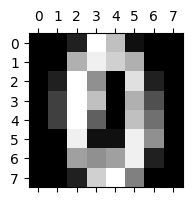

My prediction is 0
sk prediction is 0
Actual number is 0


In [13]:
idx = np.random.randint(X_test.shape[0])
dimage = X_test_org[idx].reshape((8,8))
plt.figure(figsize=(2,2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()

X_input = np.expand_dims(X_test[idx], 0)

y_pred = my_predict(l1, l2, l3, X_input)

s_pred = mlp.predict(X_input)

print('My prediction is ' + str(y_pred[0]))
print('sk prediction is ' + str(s_pred[0]))
print('Actual number is ' + str(y_test[idx]))

(c) 2026 S. W. Lee